In [7]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# 1. Load the Iris dataset
iris = load_iris()
X = iris.data
y = iris.target
target_names = iris.target_names


In [11]:
print(X[0], "---->", y[0])
print(X[57], "---->", y[57])

print(target_names)

[5.1 3.5 1.4 0.2] ----> 0
[4.9 2.4 3.3 1. ] ----> 1
['setosa' 'versicolor' 'virginica']


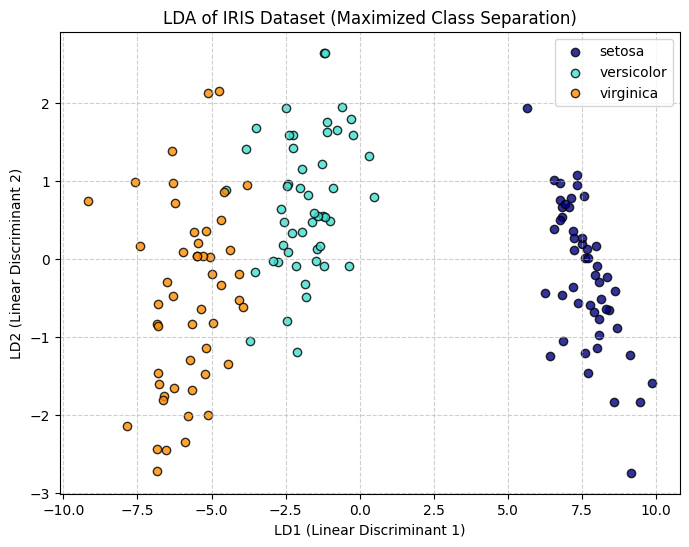

In [2]:

# 2. Apply LDA (Reduce from 4 dimensions to 2)
lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X, y)

# 3. Plot the result
plt.figure(figsize=(8, 6))
colors = ['navy', 'turquoise', 'darkorange']

for color, i, target_name in zip(colors, [0, 1, 2], target_names):
    plt.scatter(X_lda[y == i, 0], X_lda[y == i, 1], alpha=0.8, color=color,
                label=target_name, edgecolors='k')

plt.title('LDA of IRIS Dataset (Maximized Class Separation)')
plt.xlabel('LD1 (Linear Discriminant 1)')
plt.ylabel('LD2 (Linear Discriminant 2)')
plt.legend(loc='best', shadow=False, scatterpoints=1)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


## The Dimension Drop: 
The data went from 4 features (sepal/petal lengths and widths) down to just 2 axes (LD1 and LD2) without losing the identity of the flowers.

## The Perfect Split: 
Notice how Setosa is completely isolated on the right, while Versicolor and Virginica have almost zero overlap. This is the "supervised" power of LDA at work.

## The Target Limit: 
Because there are 3 flower species, the maximum number of components LDA can create is (3 - 1 = 2). It hits the mathematical limit perfectly for a 2D plot.

# What next ?

After performing LDA, you have transformed your dataset into a highly optimized, low-dimensional form. This gives you three distinct advantages for your next steps:

## 1. Build Faster, More Accurate Classifiers
Because LDA has already done the heavy lifting of separating the classes, your downstream machine learning models will perform better.

* Simple Models Win: You can now use simpler models (like Logistic Regression or Linear SVM) on the 2D data instead of complex models on the 4D data.
* No Overfitting: Reducing features from 4 to 2 reduces the risk of the model memorizing noise.
* Speed: Training a model on 2 columns is computationally faster than training on 4 (or 13 in the case of wine).

## 2. Immediate Distance-Based Classification
LDA is not just a transformer; it is also a classifier on its own. You can use the calculated axes to predict new, unseen flowers instantly.

* How it works: When a new iris flower measurement comes in, you project it onto your 2D LDA space.
* Decision Boundaries: The algorithm draws straight lines between the three clusters. Whichever side of the line the new point lands on determines its predicted species.

## 3. Build Intuitive 2D Dashboards
In a business or research setting, stakeholders cannot interpret a 4-dimensional mathematical space.

* Operational Advantage: You can plug these 2 coordinates into a live dashboard (like Tableau or PowerBI).
* Visual Monitoring: Production teams can look at a single 2D plot to see if a new batch of data is drifting into the wrong category zone.

-----------------------------

In [3]:
# Application 1) Train a simple classifier on the LDA data and print its accuracy.

from sklearn.datasets import load_iris
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

# 1. Load data and split into Train/Test sets (80% train, 20% test)
iris = load_iris()
X_train, X_test, y_train, y_test = train_test_split(
    iris.data, iris.target, test_size=0.2, random_state=42, stratify=iris.target
)

# 2. Fit LDA on the Training set and transform both sets
# (Crucial step: Always fit your dimensionality reduction on training data only)
lda = LinearDiscriminantAnalysis(n_components=2)
X_train_lda = lda.fit_transform(X_train, y_train)
X_test_lda = lda.transform(X_test)

# 3. Train a simple Logistic Regression classifier on the 2D LDA data
classifier = LogisticRegression(random_state=42)
classifier.fit(X_train_lda, y_train)

# 4. Predict on the test data and calculate accuracy
y_pred = classifier.predict(X_test_lda)
accuracy = accuracy_score(y_test, y_pred)

print(f"Classifier Accuracy on 2D LDA Data: {accuracy * 100:.2f}%")


Classifier Accuracy on 2D LDA Data: 100.00%


In [19]:
# Application 2) Part1) Use LDA to predict type of flower of a new data
import numpy as np

# Measurements for a new flower: [sepal length, sepal width, petal length, petal width]
# new_flower = np.array([[5.1, 3.5, 1.4, 0.2]]) # =X[0], actual is setosa y[0]
new_flower = np.array([[4.9, 2.4, 3.3, 1]]) # = X[57], actual is versicolor y[57]


# 1. Predict the specific class label (0, 1, or 2)
predicted_class = lda.predict(new_flower)
print(f"Predicted class: {target_names[predicted_class][0]}")

# 2. See the exact probabilities for each class
probabilities = lda.predict_proba(new_flower)
print(f"Probabilities (Setosa, Versicolor, Virginica): {probabilities[0]}")

# 3. See where it lands on your 2D scatter plot
new_flower_2d = lda.transform(new_flower)
print(f"Coordinates on your plot (LD1, LD2): {new_flower_2d[0]}")


Predicted class: versicolor
Probabilities (Setosa, Versicolor, Virginica): [1.21624258e-13 9.99999955e-01 4.47512360e-08]
Coordinates on your plot (LD1, LD2): [-0.1189231   1.59477811]


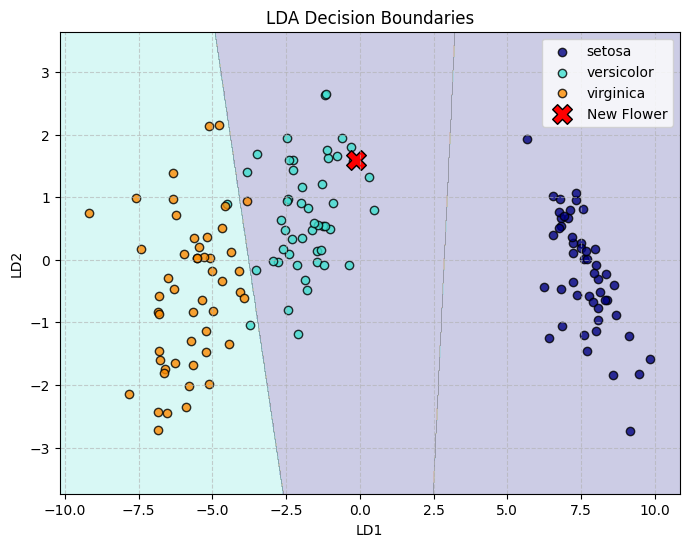

In [20]:
# part 2) Lets plot above prediction with actual data
import numpy as np
import matplotlib.pyplot as plt

# 1. Generate the grid coordinates
x_min, x_max = X_lda[:, 0].min() - 1, X_lda[:, 0].max() + 1
y_min, y_max = X_lda[:, 1].min() - 1, X_lda[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))

# 2. Train an auxiliary classifier on the 2D space to get the grid predictions
lda_plotter = LinearDiscriminantAnalysis()
lda_plotter.fit(X_lda, y)
Z = lda_plotter.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

# 3. Build the plot
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.2, colors=['navy', 'turquoise', 'darkorange'])

# Plot your original dataset points
for color, i, target_name in zip(['navy', 'turquoise', 'darkorange'], [0, 1, 2], target_names):
    plt.scatter(X_lda[y == i, 0], X_lda[y == i, 1], alpha=0.8, color=color, label=target_name, edgecolors='k')

# Example: Plotting a new incoming flower point
lda1 = new_flower_2d[0][0]
lda2 = new_flower_2d[0][1]
plt.scatter(lda1, lda2, color='red', marker='X', s=200, label='New Flower', edgecolors='black')

plt.title('LDA Decision Boundaries')
plt.xlabel('LD1')
plt.ylabel('LD2')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()
